In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

**Configurations**

In [2]:
SEED = 42

IMAGE_SIZE = 224
NUM_CLASSES = 6

BATCH_SIZE = 32

CLASS_NAMES = [
    "MT_Blowhole",
    "MT_Break",
    "MT_Crack",
    "MT_Fray",
    "MT_Free",
    "MT_Uneven"
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


**Reproducibility**

In [3]:
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "magnetic_tile"
)

print(DATASET_PATH)

d:\Study\industrial_visual_inspection\data\raw\magnetic_tile


**Load the Image Data**

In [4]:
image_paths = []
labels = []

for label, class_name in enumerate(CLASS_NAMES):

    image_folder = (
        DATASET_PATH
        / class_name
        / "Imgs"
    )

    paths = sorted(
        image_folder.glob("*.jpg")
    )

    image_paths.extend(paths)

    labels.extend(
        [label] * len(paths)
    )

print("Total images:", len(image_paths))

Total images: 1344


**Same Train/Validation/Test Split**

In [5]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 940
Validation: 202
Test: 202


**Image Transformations**

In [6]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

val_test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

`We converted the channels from 1 to 3 because it is the requirement of Pre trained Models like ResNet.`
- Also we have to normalize the image pixels data with specific means and standard deviations

**Making DataSet Class and Making Dataset objects and Dataloader objects**

In [7]:
class MagneticTileDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("L")

        label = self.labels[idx]

        if self.transform is not None:

            image = self.transform(image)

        return image, label


train_dataset = MagneticTileDataset(
    train_paths,
    train_labels,
    train_transform
)

val_dataset = MagneticTileDataset(
    val_paths,
    val_labels,
    val_test_transform
)

test_dataset = MagneticTileDataset(
    test_paths,
    test_labels,
    val_test_transform
)

**Using WeightedSampler To Get the Balanced Data In our Training and testing dataloader objects**

In [8]:
train_class_counts = Counter(
    train_labels
)

sample_weights = torch.tensor(
    [
        1.0 / train_class_counts[label]
        for label in train_labels
    ],
    dtype=torch.double
)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)

# DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(
    iter(train_loader)
)

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


**Load Pre trained ResNet18**

In [14]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Pradhuman/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 78.0MB/s]


**Freeze the Feature Extraction Layer**

In [15]:
for parameter in model.parameters():

    parameter.requires_grad = False

**Change the Classifier Layer from 512 -> 1000 (ImageNet Dataset has 1000 Classes) To 512 -> 6 (our need)**

In [16]:
model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

In [17]:
model = model.to(device)

In [18]:
# Checking total Trainable Parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 11,179,590
Trainable parameters: 3,078


In [19]:
# Parameters
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [14]:
# Training Function
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    save_path="best_resnet18.pth"
):

    best_macro_f1 = -1

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": []
    }

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        all_labels = []
        all_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_running_loss += (
                    loss.item()
                    * images.size(0)
                )

                predictions = outputs.argmax(
                    dim=1
                )

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

                all_labels.extend(
                    labels.cpu().numpy()
                )

                all_predictions.extend(
                    predictions.cpu().numpy()
                )

        val_loss = (
            val_running_loss
            / val_total
        )

        val_acc = (
            val_correct
            / val_total
        )

        val_macro_f1 = f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        history["val_macro_f1"].append(
            val_macro_f1
        )

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_macro_f1:

            best_macro_f1 = val_macro_f1

            torch.save(
                model.state_dict(),
                save_path
            )

    print(
        f"\nBest Validation Macro F1: "
        f"{best_macro_f1:.4f}"
    )

    return history

**Train Frozen ResNet18**

In [21]:
history_resnet18_frozen = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=20,
    save_path="best_resnet18_frozen.pth"
)

Epoch [1/20] | Train Loss: 1.8303 | Train Acc: 0.2053 | Val Loss: 1.6835 | Val Acc: 0.2772 | Val Macro F1: 0.1525
Epoch [2/20] | Train Loss: 1.6059 | Train Acc: 0.3436 | Val Loss: 1.5219 | Val Acc: 0.3812 | Val Macro F1: 0.2727
Epoch [3/20] | Train Loss: 1.4700 | Train Acc: 0.4574 | Val Loss: 1.5613 | Val Acc: 0.2921 | Val Macro F1: 0.2206
Epoch [4/20] | Train Loss: 1.3753 | Train Acc: 0.4809 | Val Loss: 1.2922 | Val Acc: 0.5743 | Val Macro F1: 0.3317
Epoch [5/20] | Train Loss: 1.3437 | Train Acc: 0.5011 | Val Loss: 1.3467 | Val Acc: 0.4950 | Val Macro F1: 0.2989
Epoch [6/20] | Train Loss: 1.2780 | Train Acc: 0.5149 | Val Loss: 1.6029 | Val Acc: 0.2772 | Val Macro F1: 0.2274
Epoch [7/20] | Train Loss: 1.2327 | Train Acc: 0.5532 | Val Loss: 1.2928 | Val Acc: 0.4901 | Val Macro F1: 0.3001
Epoch [8/20] | Train Loss: 1.2175 | Train Acc: 0.5564 | Val Loss: 1.2562 | Val Acc: 0.4901 | Val Macro F1: 0.3696
Epoch [9/20] | Train Loss: 1.1697 | Train Acc: 0.5968 | Val Loss: 1.2779 | Val Acc: 0.47

In [22]:
# Load the best Frozen Model
model.load_state_dict(
    torch.load(
        "best_resnet18_frozen.pth",
        map_location=device
    )
)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [15]:
# Evaluation Function

def evaluate_model(
    model,
    test_loader,
    device
):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = (
                outputs
                .argmax(dim=1)
                .cpu()
            )

            all_predictions.extend(
                predictions.numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        all_labels,
        all_predictions
    )

    print(
        f"Accuracy:          {accuracy:.4f}"
    )

    print(
        f"Balanced Accuracy: {balanced_accuracy:.4f}"
    )

    print(
        f"Macro F1:          {macro_f1:.4f}"
    )

    print(
        f"MCC:               {mcc:.4f}"
    )

    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1,
        "mcc": mcc,
        "labels": all_labels,
        "predictions": all_predictions
    }

In [24]:
# Evaluate The ResNet18
resnet18_frozen_results = evaluate_model(
    model,
    test_loader,
    device
)

Accuracy:          0.5990
Balanced Accuracy: 0.5877
Macro F1:          0.4777
MCC:               0.3684

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole       0.36      0.50      0.42        18
    MT_Break       0.29      0.50      0.36        12
    MT_Crack       0.50      0.44      0.47         9
     MT_Fray       0.36      0.80      0.50         5
     MT_Free       0.87      0.62      0.72       143
   MT_Uneven       0.28      0.67      0.39        15

    accuracy                           0.60       202
   macro avg       0.44      0.59      0.48       202
weighted avg       0.72      0.60      0.63       202



`Now Comes The most important Part`
- We will unfreeze ResNet
- Fine Tune The Optimizer and Then Fine-Tune the ResNet Model on our Magnetic Tile Dataset


**Unfreeze the Layers**

In [25]:
for parameter in model.parameters():

    parameter.requires_grad = True

In [26]:
# New Optimizer Much lower learning Rate
optimizer_finetune = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

Why smaller?

`Because we don't want to destroy useful pretrained representations.`

**Fine Tune The Model**

In [27]:
history_resnet18_finetuned = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_finetune,
    device=device,
    epochs=20,
    save_path="best_resnet18_finetuned.pth"
)

Epoch [1/20] | Train Loss: 0.9239 | Train Acc: 0.6670 | Val Loss: 0.9971 | Val Acc: 0.5941 | Val Macro F1: 0.4413
Epoch [2/20] | Train Loss: 0.7646 | Train Acc: 0.7447 | Val Loss: 0.9770 | Val Acc: 0.5842 | Val Macro F1: 0.4438
Epoch [3/20] | Train Loss: 0.6902 | Train Acc: 0.7904 | Val Loss: 1.0103 | Val Acc: 0.5941 | Val Macro F1: 0.5209
Epoch [4/20] | Train Loss: 0.5929 | Train Acc: 0.8266 | Val Loss: 0.9701 | Val Acc: 0.6040 | Val Macro F1: 0.5088
Epoch [5/20] | Train Loss: 0.5430 | Train Acc: 0.8457 | Val Loss: 0.8650 | Val Acc: 0.6683 | Val Macro F1: 0.5680
Epoch [6/20] | Train Loss: 0.4781 | Train Acc: 0.8638 | Val Loss: 0.8489 | Val Acc: 0.6782 | Val Macro F1: 0.6041
Epoch [7/20] | Train Loss: 0.4612 | Train Acc: 0.8649 | Val Loss: 0.8043 | Val Acc: 0.6931 | Val Macro F1: 0.5952
Epoch [8/20] | Train Loss: 0.3978 | Train Acc: 0.8904 | Val Loss: 0.8114 | Val Acc: 0.6782 | Val Macro F1: 0.5809
Epoch [9/20] | Train Loss: 0.3588 | Train Acc: 0.8872 | Val Loss: 0.8455 | Val Acc: 0.64

In [28]:
# Load the Best Fine Tuned Model
model.load_state_dict(
    torch.load(
        "best_resnet18_finetuned.pth",
        map_location=device
    )
)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [29]:
# Final ResNet Evaluation
resnet18_finetuned_results = evaluate_model(
    model,
    test_loader,
    device
)

Accuracy:          0.8614
Balanced Accuracy: 0.8603
Macro F1:          0.7676
MCC:               0.7424

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole       0.76      0.89      0.82        18
    MT_Break       0.58      0.58      0.58        12
    MT_Crack       0.62      0.89      0.73         9
     MT_Fray       0.56      1.00      0.71         5
     MT_Free       0.96      0.87      0.91       143
   MT_Uneven       0.78      0.93      0.85        15

    accuracy                           0.86       202
   macro avg       0.71      0.86      0.77       202
weighted avg       0.88      0.86      0.87       202



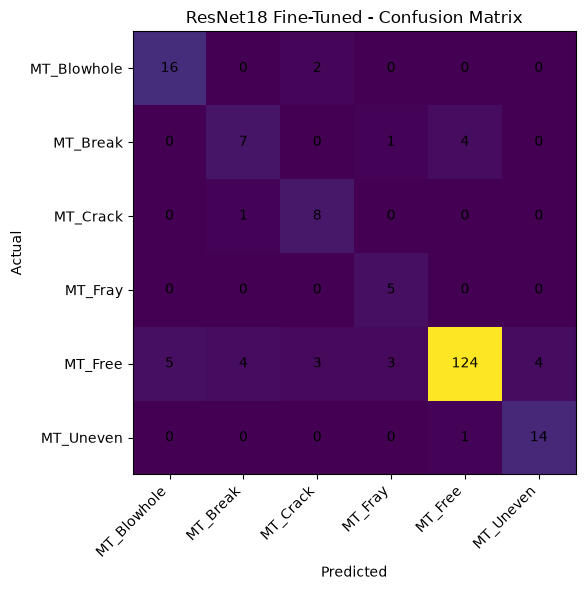

In [30]:
cm = confusion_matrix(
    resnet18_finetuned_results["labels"],
    resnet18_finetuned_results["predictions"]
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "ResNet18 Fine-Tuned - Confusion Matrix"
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

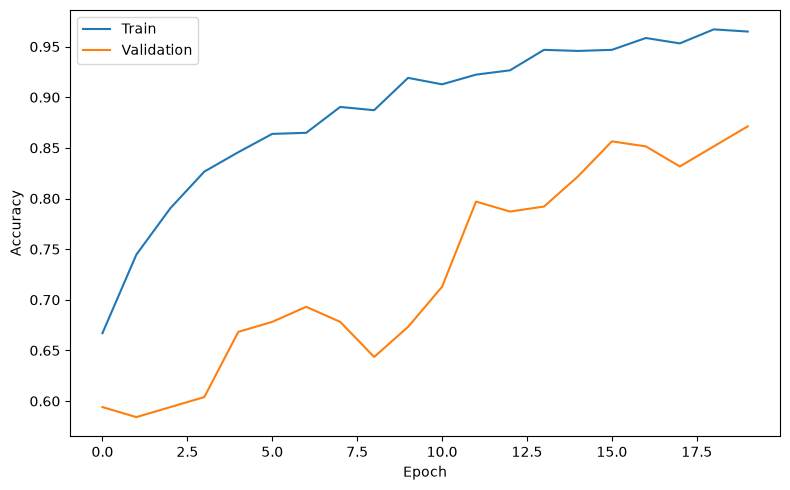

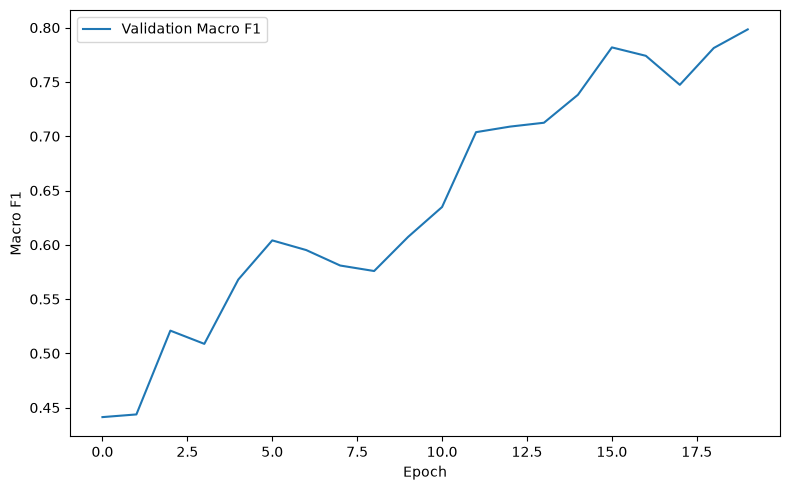

In [31]:
# Training Curves

plt.figure(figsize=(8, 5))

plt.plot(
    history_resnet18_finetuned["train_acc"],
    label="Train"
)

plt.plot(
    history_resnet18_finetuned["val_acc"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history_resnet18_finetuned["val_macro_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.legend()

plt.tight_layout()

plt.show()

In [32]:
# Model Comparison B/w Frozen ResNet and Unfrozen/Fine-Tuned ResNet18 on our data
comparison = pd.DataFrame([
    {
        "Model": "ComplexCNN + Optuna",
        "Parameters": 1_200_000,
        "Accuracy": 0.8911,
        "Balanced Accuracy": 0.6951,
        "Macro F1": 0.7268,
        "MCC": 0.765
    },
    {
        "Model": "ResNet18 Frozen",
        "Parameters": sum(
            p.numel()
            for p in model.parameters()
        ),
        "Accuracy": resnet18_frozen_results["accuracy"],
        "Balanced Accuracy": resnet18_frozen_results["balanced_accuracy"],
        "Macro F1": resnet18_frozen_results["macro_f1"],
        "MCC": resnet18_frozen_results["mcc"]
    },
    {
        "Model": "ResNet18 Fine-Tuned",
        "Parameters": sum(
            p.numel()
            for p in model.parameters()
        ),
        "Accuracy": resnet18_finetuned_results["accuracy"],
        "Balanced Accuracy": resnet18_finetuned_results["balanced_accuracy"],
        "Macro F1": resnet18_finetuned_results["macro_f1"],
        "MCC": resnet18_finetuned_results["mcc"]
    }
])

comparison

,Model,Parameters,Accuracy,Balanced Accuracy,Macro F1,MCC
0,ComplexCNN + Optuna,1200000,0.891100,0.695100,0.726800,0.765000
1,ResNet18 Frozen,11179590,0.599010,0.587749,0.477716,0.368432
2,ResNet18 Fine-Tuned,11179590,0.861386,0.860263,0.767609,0.742431


**Observations**
`We can now say something meaningful:`

- Transfer learning was not beneficial when the pre trained ResNet18 backbone was frozen. However, fine-tuning the pre trained network substantially improved class-balanced performance, indicating that adaptation of the pre trained representation to the magnetic-tile domain was necessary.


### Let us Try To Unfreeze Only 4th Convolution Layer And FC Layer Instead of Fully Unfreezing ResNet

In [34]:
weights = models.ResNet18_Weights.DEFAULT

model_partial = models.resnet18(
    weights=weights
)

model_partial.fc = nn.Linear(
    model_partial.fc.in_features,
    NUM_CLASSES
)

# Freeze Everything First
for parameter in model_partial.parameters():
    parameter.requires_grad = False

# Unfreeze Only Layer 4 and Classifier Layer
for parameter in model_partial.layer4.parameters():
    parameter.requires_grad = True

for parameter in model_partial.fc.parameters():
    parameter.requires_grad = True

model_partial = model_partial.to(device)

# Check Total Trainable Parameters
trainable_params = sum(
    p.numel()
    for p in model_partial.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model_partial.parameters()
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 11,179,590
Trainable parameters: 8,396,806


In [35]:
# Using Small Learning Rate
criterion = nn.CrossEntropyLoss()

optimizer_partial = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_partial.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

In [36]:
# Train the Partial Unfrozen Model
history_resnet18_partial = train_model(
    model=model_partial,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_partial,
    device=device,
    epochs=20,
    save_path="best_resnet18_partial.pth"
)

Epoch [1/20] | Train Loss: 1.4433 | Train Acc: 0.4383 | Val Loss: 1.8356 | Val Acc: 0.2129 | Val Macro F1: 0.2902
Epoch [2/20] | Train Loss: 0.8748 | Train Acc: 0.6989 | Val Loss: 1.2275 | Val Acc: 0.4208 | Val Macro F1: 0.4529
Epoch [3/20] | Train Loss: 0.5505 | Train Acc: 0.8330 | Val Loss: 0.8650 | Val Acc: 0.6931 | Val Macro F1: 0.6081
Epoch [4/20] | Train Loss: 0.3915 | Train Acc: 0.8809 | Val Loss: 0.7639 | Val Acc: 0.7129 | Val Macro F1: 0.6150
Epoch [5/20] | Train Loss: 0.3017 | Train Acc: 0.9000 | Val Loss: 0.5662 | Val Acc: 0.8020 | Val Macro F1: 0.6968
Epoch [6/20] | Train Loss: 0.2110 | Train Acc: 0.9436 | Val Loss: 0.4125 | Val Acc: 0.8564 | Val Macro F1: 0.7796
Epoch [7/20] | Train Loss: 0.2088 | Train Acc: 0.9404 | Val Loss: 0.5918 | Val Acc: 0.8020 | Val Macro F1: 0.7276
Epoch [8/20] | Train Loss: 0.1526 | Train Acc: 0.9628 | Val Loss: 0.3404 | Val Acc: 0.8861 | Val Macro F1: 0.8055
Epoch [9/20] | Train Loss: 0.1594 | Train Acc: 0.9596 | Val Loss: 0.4492 | Val Acc: 0.87

In [37]:
# Evaluate

model_partial.load_state_dict(
    torch.load(
        "best_resnet18_partial.pth",
        map_location=device
    )
)

partial_results = evaluate_model(
    model_partial,
    test_loader,
    device
)

Accuracy:          0.9356
Balanced Accuracy: 0.8750
Macro F1:          0.8745
MCC:               0.8636

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole       0.94      0.89      0.91        18
    MT_Break       0.86      0.50      0.63        12
    MT_Crack       1.00      0.89      0.94         9
     MT_Fray       0.71      1.00      0.83         5
     MT_Free       0.95      0.97      0.96       143
   MT_Uneven       0.94      1.00      0.97        15

    accuracy                           0.94       202
   macro avg       0.90      0.87      0.87       202
weighted avg       0.94      0.94      0.93       202



In [38]:
partial_resnet_result = {
    "Model": "ResNet18 Partial Fine-Tuned",
    "Parameters": sum(
        p.numel()
        for p in model_partial.parameters()
    ),
    "Accuracy": 0.9356,
    "Balanced Accuracy": 0.8750,
    "Macro F1": 0.8745,
    "MCC": 0.8636
}

comparison = pd.concat(
    [
        comparison,
        pd.DataFrame([partial_resnet_result])
    ],
    ignore_index=True
)

comparison

,Model,Parameters,Accuracy,Balanced Accuracy,Macro F1,MCC
0,ComplexCNN + Optuna,1200000,0.891100,0.695100,0.726800,0.765000
1,ResNet18 Frozen,11179590,0.599010,0.587749,0.477716,0.368432
2,ResNet18 Fine-Tuned,11179590,0.861386,0.860263,0.767609,0.742431
3,ResNet18 Partial Fine-Tuned,11179590,0.935600,0.875000,0.874500,0.863600


## Observation — ResNet18 Partial Fine-Tuning

The ResNet18 partial fine-tuning experiment produced the strongest classification performance observed so far.

The model achieved **93.56% accuracy, 87.50% balanced accuracy, 87.45% macro F1, and an MCC of 0.8636** on the held-out test set.

Compared with the frozen ResNet18, partial fine-tuning produced a substantial improvement, demonstrating that the generic ImageNet features were not sufficient by themselves and that adapting the deeper representation to the magnetic-tile domain was necessary.

Partial fine-tuning also outperformed full-network fine-tuning across all major evaluation metrics. This suggests that updating only the deeper ResNet representation and classification head was sufficient for domain adaptation, while keeping the earlier pretrained layers fixed helped preserve useful generic visual features and may have reduced overfitting on the small dataset.

The class-wise results were strong for most classes:

- **MT_Blowhole:** F1 = 0.91
- **MT_Break:** F1 = 0.63
- **MT_Crack:** F1 = 0.94
- **MT_Fray:** F1 = 0.83
- **MT_Free:** F1 = 0.96
- **MT_Uneven:** F1 = 0.97

`MT_Break` remains the weakest class, with a recall of 0.50, indicating that it is still the most difficult defect class to identify.

Overall, **ResNet18 with partial fine-tuning is currently the strongest classification model in the project**, outperforming the Optuna-tuned custom CNN in balanced accuracy, macro F1, and MCC while achieving higher overall accuracy as well.

In [17]:
weights = models.ResNet18_Weights.DEFAULT

model_partial3_4 = models.resnet18(
    weights=weights
)

model_partial3_4.fc = nn.Linear(
    model_partial.fc.in_features,
    NUM_CLASSES
)

# Freeze Everything First
for parameter in model_partial3_4.parameters():
    parameter.requires_grad = False

# Unfreeze Layer 3 and Layer 4 and Classifier Layer
for parameter in model_partial3_4.layer3.parameters():
    parameter.requires_grad = True

for parameter in model_partial3_4.layer4.parameters():
    parameter.requires_grad = True

for parameter in model_partial3_4.fc.parameters():
    parameter.requires_grad = True

model_partial3_4 = model_partial3_4.to(device)

# Check Total Trainable Parameters
trainable_params = sum(
    p.numel()
    for p in model_partial3_4.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model_partial3_4.parameters()
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 11,179,590
Trainable parameters: 10,496,518


In [18]:
# Using Small Learning Rate
criterion = nn.CrossEntropyLoss()

optimizer_partial3_4 = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_partial3_4.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

In [19]:
# Train the Partial Unfrozen Model
history_resnet18_partial3_4 = train_model(
    model=model_partial3_4,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_partial3_4,
    device=device,
    epochs=20,
    save_path="best_resnet18_partial3_4.pth"
)

Epoch [1/20] | Train Loss: 1.3156 | Train Acc: 0.5085 | Val Loss: 1.6458 | Val Acc: 0.2228 | Val Macro F1: 0.2651
Epoch [2/20] | Train Loss: 0.6572 | Train Acc: 0.8000 | Val Loss: 1.2021 | Val Acc: 0.4703 | Val Macro F1: 0.5090
Epoch [3/20] | Train Loss: 0.3877 | Train Acc: 0.8862 | Val Loss: 0.6044 | Val Acc: 0.7921 | Val Macro F1: 0.7160
Epoch [4/20] | Train Loss: 0.2233 | Train Acc: 0.9426 | Val Loss: 0.4474 | Val Acc: 0.8465 | Val Macro F1: 0.7734
Epoch [5/20] | Train Loss: 0.2007 | Train Acc: 0.9447 | Val Loss: 0.3445 | Val Acc: 0.9109 | Val Macro F1: 0.8480
Epoch [6/20] | Train Loss: 0.1595 | Train Acc: 0.9511 | Val Loss: 0.2415 | Val Acc: 0.9356 | Val Macro F1: 0.8779
Epoch [7/20] | Train Loss: 0.1104 | Train Acc: 0.9691 | Val Loss: 0.3041 | Val Acc: 0.9208 | Val Macro F1: 0.8447
Epoch [8/20] | Train Loss: 0.0912 | Train Acc: 0.9851 | Val Loss: 0.2513 | Val Acc: 0.9406 | Val Macro F1: 0.8728
Epoch [9/20] | Train Loss: 0.0770 | Train Acc: 0.9819 | Val Loss: 0.2027 | Val Acc: 0.96

In [22]:
# Evaluate

model_partial3_4.load_state_dict(
    torch.load(
        "best_resnet18_partial3_4.pth",
        map_location=device
    )
)

torch.save(
    model_partial3_4,
    "resnet18_partial3_4_full.pth"
)

partial_results = evaluate_model(
    model_partial3_4,
    test_loader,
    device
)

Accuracy:          0.9554
Balanced Accuracy: 0.8810
Macro F1:          0.9139
MCC:               0.9054

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole       0.89      0.94      0.92        18
    MT_Break       0.89      0.67      0.76        12
    MT_Crack       1.00      0.89      0.94         9
     MT_Fray       1.00      0.80      0.89         5
     MT_Free       0.96      0.99      0.97       143
   MT_Uneven       1.00      1.00      1.00        15

    accuracy                           0.96       202
   macro avg       0.96      0.88      0.91       202
weighted avg       0.96      0.96      0.95       202



In [21]:
partial_resnet_result = {
    "Model": "ResNet18 Partial Layer 3-4 Fine-Tuned",
    "Parameters": sum(
        p.numel()
        for p in model_partial3_4.parameters()
    ),
    "Accuracy": 0.9554,
    "Balanced Accuracy": 0.8810,
    "Macro F1": 0.9139,
    "MCC": 0.9054
}

comparison = pd.concat(
    [
        comparison,
        pd.DataFrame([partial_resnet_result])
    ],
    ignore_index=True
)

comparison

NameError: name 'comparison' is not defined

| Model                                 |   Accuracy | Balanced Accuracy |   Macro F1 |        MCC |
| ------------------------------------- | ---------: | ----------------: | ---------: | ---------: |
| Baseline CNN + Optuna                 |     89.11% |            69.51% |     72.68% |      0.765 |
| ResNet18 Frozen                       |     59.90% |            58.77% |     47.77% |      0.368 |
| ResNet18 Full FT                      |     86.14% |            86.03% |     76.76% |      0.742 |
| ResNet18 Partial FT — Layer 4         |     93.56% |            87.50% |     87.45% |     0.8636 |
| EfficientNet-B0 Frozen                |     46.53% |            63.95% |     46.16% |     0.3529 |
| EfficientNet-B0 Partial FT            |     68.81% |            76.07% |     62.65% |     0.5517 |
| **ResNet18 Partial FT — Layer 3 + 4** | **95.54%** |        **88.10%** | **91.39%** | **0.9054** |